In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
def f1_score(Y_true, Y_pred):
    f1s=[]
    for label in np.unique(Y_true):
        tp=np.sum((Y_pred==label) & (Y_true==label))
        fp=np.sum((Y_pred==label) & (Y_true!=label))
        fn=np.sum((Y_pred!=label) & (Y_true==label))

        precision = tp/(tp+fp) if (tp+fp) > 0 else 0
        recall = tp/(tp+fn) if (tp+fn) > 0 else 0
        f1 = 2 *precision*recall/(precision+recall) if (precision+recall) > 0 else 0
        f1s.append(f1)

    return np.mean(f1s)

In [ ]:
def knn_predict(X_train, Y_train, test_point, k_max=20, beta=1.0, sigma_mode="mean"):

    distances = np.sqrt(np.sum((X_train.values - test_point.values)**2, axis=1))

    sorted_indices = np.argsort(distances)
    sorted_distances = distances[sorted_indices]
    sorted_labels = Y_train.iloc[sorted_indices].values

    diffs = np.diff(sorted_distances[:k_max])

    if len(diffs) == 0:
        k = 1
    else:
        threshold = np.mean(diffs) + beta * np.std(diffs)  ##threshold with beta hyperparamter for changing threshold
        k = k_max
        for i, d in enumerate(diffs):
            if d > threshold:
                k = i + 1
                break
    k = max(1, k)
    if sigma_mode == "mean": ## sigma hyperparamater
        sigma = np.mean(sorted_distances[:k])
    elif sigma_mode == "median":
        sigma = np.median(sorted_distances[:k])
    else:
        raise ValueError("sigma_mode must be 'mean' or 'median'")

    sigma = sigma + 1e-8  # avoid division by zero

    weights = np.exp(-(sorted_distances[:k]**2) / (2 * sigma**2)) ## weighted voting
    label_weights = {}
    for label, w in zip(sorted_labels[:k], weights):
        label_weights[label] = label_weights.get(label, 0) + w
    return max(label_weights, key=label_weights.get)

def knn_accuracy(X_train, Y_train, X_test, Y_test, k):
    correct=0
    for i in range(len(X_test)):
        value=knn_predict(X_train, Y_train, X_test.iloc[i], k)
        if value==Y_test.iloc[i]:
            correct+=1
    return correct/len(X_test)

In [ ]:
#Returns predictions for all the test points
def knn_predictions(X_train, Y_train, X_test, k_max=20, beta=1.0, sigma_mode="mean"):
    preds = []
    for i in range(len(X_test)):
        pred = knn_predict(
            X_train,
            Y_train,
            X_test.iloc[i],
            k_max=k_max,
            beta=beta,
            sigma_mode=sigma_mode
        )
        preds.append(pred)
    return np.array(preds)

In [ ]:
#Stratified K-Fold split
def stratified_k_fold(Y, k=10):
    folds=[[] for _ in range(k)]

    for label in Y.unique():
        indices=np.where(Y==label)[0]
        np.random.shuffle(indices)
        for i, idx in enumerate(indices):
            folds[i%k].append(idx)

    return folds

In [ ]:
def evaluate_knn(X, Y, k_max, beta=1.0, sigma_mode="mean", n_folds=10):
    np.random.seed(67)
    folds = stratified_k_fold(Y, n_folds)
    accuracies = []
    f1_scores = []

    for i in range(n_folds):
        test_idx = folds[i]
        train_idx = [idx for j in range(n_folds) if j != i for idx in folds[j]]

        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        Y_train, Y_test = Y.iloc[train_idx], Y.iloc[test_idx]

        train_min = X_train.min()
        train_max = X_train.max()
        denom = (train_max - train_min).replace(0, 1)

        X_train_norm = (X_train - train_min) / denom
        X_test_norm = (X_test - train_min) / denom
        preds = knn_predictions(X_train_norm, Y_train, X_test_norm, k_max=k_max, beta=beta, sigma_mode=sigma_mode)
        acc = np.mean(preds == Y_test.values)
        f1 = f1_score(Y_test.values, preds)

        accuracies.append(acc)
        f1_scores.append(f1)

    return np.mean(accuracies), np.mean(f1_scores)

In [ ]:
def plot_best_results(k_values, accs, f1s, title="KNN Performance"):
    print(accs,f1s)
    plt.figure(figsize=(8,6))

    plt.plot(k_values, accs, marker='o', label="Accuracy")
    plt.plot(k_values, f1s, marker='s', label="F1 Score")

    plt.xlabel("k_max")
    plt.ylabel("Score")
    plt.title(title)
    plt.legend()
    plt.grid(True)

    plt.show()

In [ ]:
def evaluate_over_k(X, Y, k_values, beta, sigma_mode):
    accs = []
    f1s = []

    for k in k_values:
        acc, f1 = evaluate_knn(X, Y, k_max=k, beta=beta, sigma_mode=sigma_mode)
        accs.append(acc)
        f1s.append(f1)

    return accs, f1s


def find_best_params_with_curves(X, Y, k_values, beta_values, sigma_modes):
    best_score = -1
    best_config = None
    best_accs = None
    best_f1s = None

    for beta in beta_values:
        for sigma in sigma_modes:
            accs, f1s = evaluate_over_k(X, Y, k_values, beta, sigma)

            avg_f1 = np.mean(f1s)

            if avg_f1 > best_score:
                best_score = avg_f1
                best_config = (beta, sigma)
                best_accs = accs
                best_f1s = f1s

    return best_config, best_accs, best_f1s

def run_all_datasets(datasets, k_values, beta_values, sigma_modes):
    results = {}

    for name, (X, Y) in datasets.items():
        print(f"Processing {name}...")

        best_config, accs, f1s = find_best_params_with_curves(
            X, Y, k_values, beta_values, sigma_modes
        )

        results[name] = {
            "config": best_config,
            "accs": accs,
            "f1s": f1s
        }

        plot_best_results(
            k_values,
            accs,
            f1s,
            title=f"{name} | beta={best_config[0]}, sigma={best_config[1]}"
        )

    return results

Processing Dataset 1...
[np.float64(0.8860892388451443), np.float64(0.8860892388451443), np.float64(0.9097112860892388), np.float64(0.9086614173228347), np.float64(0.9220472440944881), np.float64(0.9186351706036746), np.float64(0.9131233595800525), np.float64(0.9073490813648293), np.float64(0.9078740157480315), np.float64(0.9070866141732283), np.float64(0.9062992125984252), np.float64(0.9062992125984254), np.float64(0.9060367454068242), np.float64(0.9052493438320208), np.float64(0.9047244094488189), np.float64(0.9039370078740158), np.float64(0.9034120734908138), np.float64(0.9015748031496065), np.float64(0.9026246719160106), np.float64(0.9018372703412074)] [np.float64(0.8838019169352898), np.float64(0.8838019169352898), np.float64(0.9077002859210239), np.float64(0.9066758928760803), np.float64(0.9202387207605345), np.float64(0.9168626844856943), np.float64(0.9113058977884432), np.float64(0.9053663154064753), np.float64(0.9059461137740715), np.float64(0.9050951799794749), np.float64(0.9

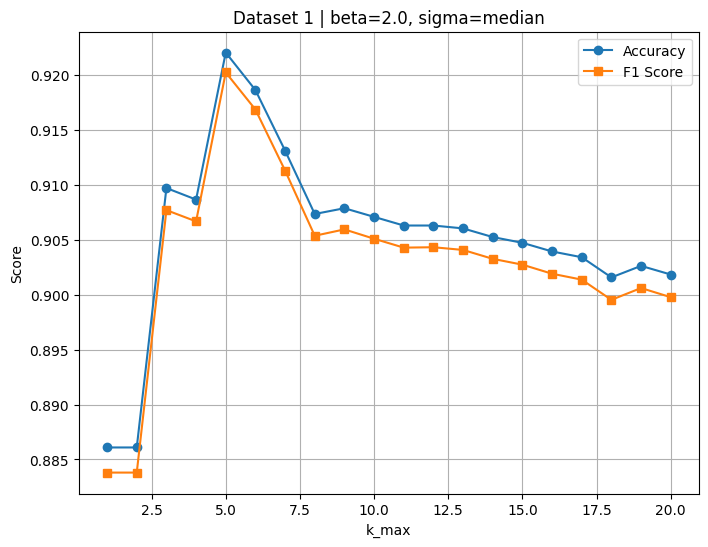

Processing Dataset 2...
[np.float64(0.9588888888888889), np.float64(0.9588888888888889), np.float64(0.9439181286549706), np.float64(0.9591812865497076), np.float64(0.9541812865497075), np.float64(0.9541812865497075), np.float64(0.9541812865497075), np.float64(0.9591812865497076), np.float64(0.9641812865497075), np.float64(0.9541812865497075), np.float64(0.9644444444444444), np.float64(0.9644444444444444), np.float64(0.9644444444444444), np.float64(0.9644444444444444), np.float64(0.9644444444444444), np.float64(0.9644444444444444), np.float64(0.9644444444444444), np.float64(0.9644444444444444), np.float64(0.9644444444444444), np.float64(0.9588888888888889)] [np.float64(0.9455791561464532), np.float64(0.9455791561464532), np.float64(0.927701114647722), np.float64(0.9480488448230384), np.float64(0.9408803860416765), np.float64(0.9408803860416765), np.float64(0.9408803860416765), np.float64(0.9480488448230384), np.float64(0.9536840142513112), np.float64(0.9395923036044003), np.float64(0.95

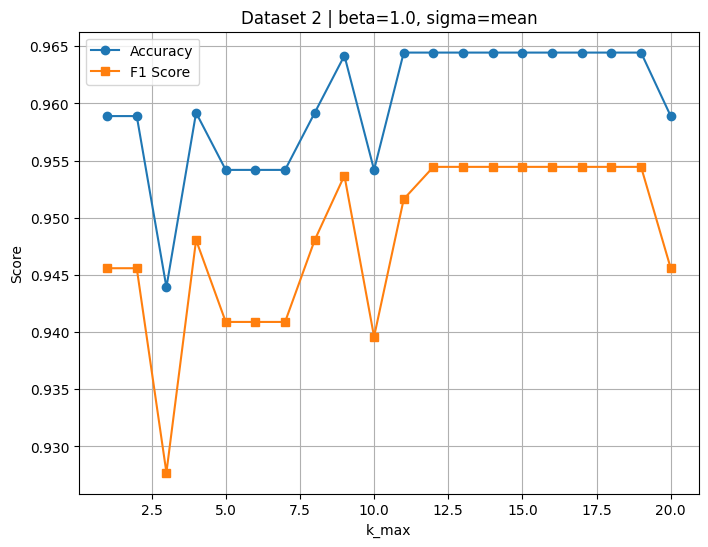

Processing Dataset 3...
[np.float64(0.9871730560863281), np.float64(0.9871730560863281), np.float64(0.9871730560863281), np.float64(0.9866175005307726), np.float64(0.9866175005307726), np.float64(0.9866175005307726), np.float64(0.9866175005307726), np.float64(0.9866175005307726), np.float64(0.9866175005307726), np.float64(0.9866175005307726), np.float64(0.9866175005307726), np.float64(0.9871730560863281), np.float64(0.9871730560863281), np.float64(0.9871730560863281), np.float64(0.9871730560863281), np.float64(0.9871730560863281), np.float64(0.9871730560863281), np.float64(0.9871730560863281), np.float64(0.9871730560863281), np.float64(0.9871730560863281)] [np.float64(0.9871459015387035), np.float64(0.9871459015387035), np.float64(0.9871459015387035), np.float64(0.986591708690393), np.float64(0.986591708690393), np.float64(0.986591708690393), np.float64(0.986591708690393), np.float64(0.986591708690393), np.float64(0.986591708690393), np.float64(0.986591708690393), np.float64(0.98659170

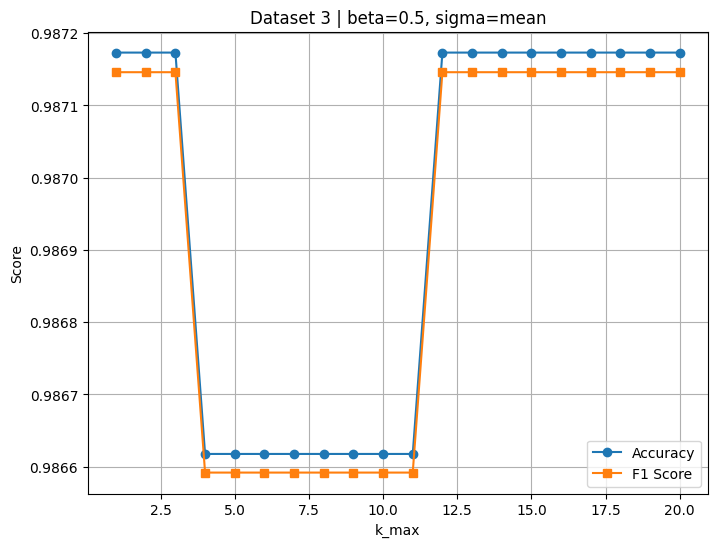

Processing Dataset 4...
[np.float64(0.8221401515151514), np.float64(0.8221401515151514), np.float64(0.8543597027972029), np.float64(0.8572479603729605), np.float64(0.8649176864801864), np.float64(0.867995337995338), np.float64(0.857436625874126), np.float64(0.8528678613053613), np.float64(0.8528678613053613), np.float64(0.8513053613053613), np.float64(0.8513053613053613), np.float64(0.8513527097902098), np.float64(0.8513527097902098), np.float64(0.8513527097902098), np.float64(0.8529152097902098), np.float64(0.8529152097902098), np.float64(0.8529152097902098), np.float64(0.8513527097902098), np.float64(0.8513527097902098), np.float64(0.8513527097902098)] [np.float64(0.8199462335274376), np.float64(0.8199462335274376), np.float64(0.8523313932866323), np.float64(0.855555820690773), np.float64(0.8632977107199544), np.float64(0.8663829416967002), np.float64(0.8556456931974636), np.float64(0.8510422625125557), np.float64(0.8510607079373163), np.float64(0.8494105716526184), np.float64(0.8494

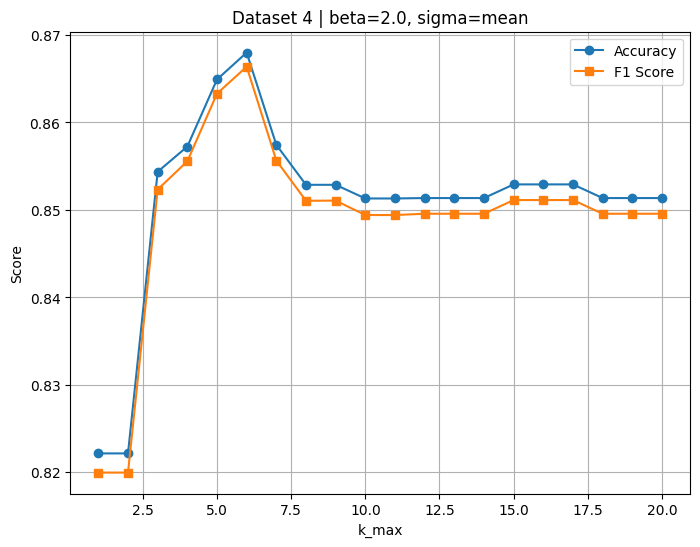

Processing Dataset 5...


KeyboardInterrupt: 

In [ ]:
#Running KNN on Rice dataset
import matplotlib.pyplot as plt

data=pd.read_csv("preprocessed_datasets/rice_processed.csv")
X1=data.iloc[:, :-1]
Y1=data.iloc[:, -1]
data=pd.read_csv("preprocessed_datasets/parkinsons_processed.csv")
X2=data.iloc[:, :-1]
Y2=data.iloc[:, -1]
data=pd.read_csv("preprocessed_datasets/digits_processed.csv")
X3=data.iloc[:, :-1]
Y3=data.iloc[:, -1]
data=pd.read_csv("preprocessed_datasets/credit_processed.csv")
X4=data.iloc[:, :-1]
Y4=data.iloc[:, -1]
data=pd.read_csv("preprocessed_datasets/student_dropout_processed.csv")
X5=data.iloc[:, :-1]
Y5=data.iloc[:, -1]
datasets = {
    "Dataset 1": (X1, Y1),
    "Dataset 2": (X2, Y2),
    "Dataset 3": (X3, Y3),
    "Dataset 4": (X4, Y4),
    "Dataset 5": (X5, Y5),
}

k_values = list(range(1, 21))
beta_values = [0.5, 1.0, 1.5, 2.0]
sigma_modes = ["mean", "median"]

results = run_all_datasets(datasets, k_values, beta_values, sigma_modes)

